# Brain Map Classification Pipeline

This notebook demonstrates the complete pipeline for categorizing neuroimaging brain maps into semantic categories.

## Pipeline Overview

1. **LLM Categorization**: Use Claude to categorize ~2,458 ngram labels into 5 categories
2. **Dataset Creation**: Build paper-level labeled dataset
3. **Model Training**: Train multiple classifiers (PCA+Ridge, XGBoost, Neural Net)
4. **Evaluation**: Compare and analyze results

## Target Categories
- Networks: DMN, salience network, etc.
- Regions: precuneus, hippocampus, etc.
- Cognitive_Functions: working memory, attention, etc.
- Tasks: n-back, Stroop, etc.
- Conditions: depression, schizophrenia, etc.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Part 1: Data Inspection

Let's first load and inspect the raw ngram data.

In [2]:
# Load ngram data
labels = np.load('ngram_labels.npy', allow_pickle=True)
matrix = np.load('ngram_matrix.npy', allow_pickle=True)

with open('pmids.txt', 'r') as f:
    pmids = [line.strip() for line in f if line.strip() != 'pmid']

print(f"Number of labels: {len(labels)}")
print(f"Matrix shape: {matrix.shape}")
print(f"Number of PMIDs: {len(pmids)}")
print(f"\nMatrix sparsity: {(matrix == 0).sum() / matrix.size:.2%}")
print(f"Average labels per paper: {matrix.sum(axis=1).mean():.2f}")

Number of labels: 2458
Matrix shape: (30826, 2458)
Number of PMIDs: 30826

Matrix sparsity: 99.10%
Average labels per paper: 22.21


In [3]:
# Sample labels
print("Sample labels:")
sample_indices = np.random.choice(len(labels), 20, replace=False)
for idx in sorted(sample_indices):
    print(f"  {labels[idx]}")

Sample labels:
  bases
  copd
  haptic
  intact
  meta
  minute
  motion
  needs
  safe
  tesla
  tonal
  areas right
  attentional bias
  clinical features
  fc patterns
  inter network
  posterior cortical
  right cuneus
  fusiform gyrus right
  stress disorder ptsd


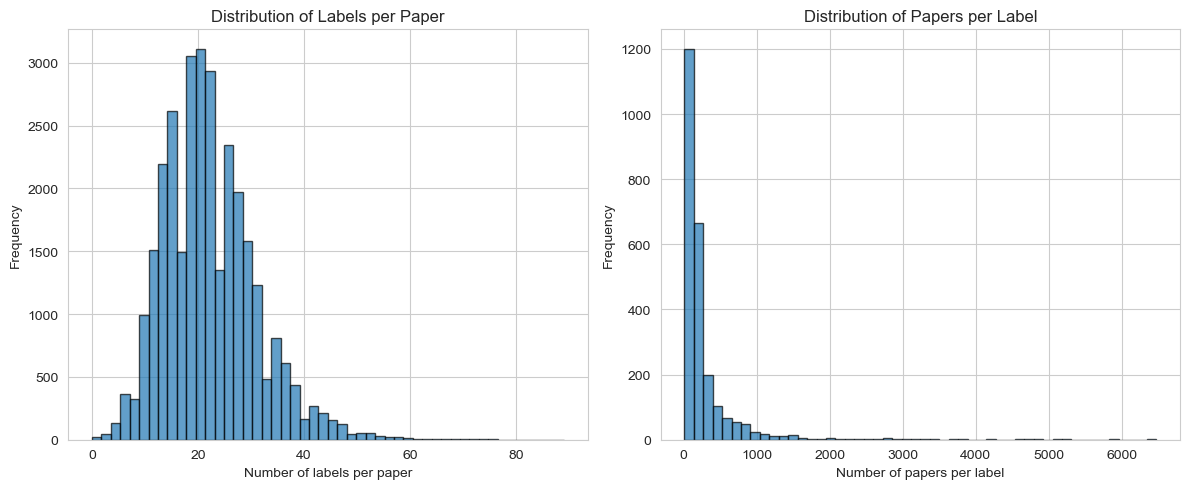

In [4]:
# Distribution of labels per paper
labels_per_paper = matrix.sum(axis=1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(labels_per_paper, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of labels per paper')
plt.ylabel('Frequency')
plt.title('Distribution of Labels per Paper')

plt.subplot(1, 2, 2)
papers_per_label = matrix.sum(axis=0)
plt.hist(papers_per_label, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of papers per label')
plt.ylabel('Frequency')
plt.title('Distribution of Papers per Label')

plt.tight_layout()
plt.show()

## Part 2: LLM Label Categorization

In [5]:
# Load categorization results
import json

with open('label_categories.json', 'r') as f:
    label_categories = json.load(f)

print(f"Categorized labels: {len(label_categories)}")

# Analyze category distribution
categories = ["Networks", "Regions", "Cognitive_Functions", "Tasks", "Conditions"]
category_counts = {cat: 0 for cat in categories}

for label, cats in label_categories.items():
    for cat, is_member in cats.items():
        if is_member:
            category_counts[cat] += 1

print("\nLabels per category:")
for cat, count in category_counts.items():
    print(f"  {cat}: {count} ({count/len(label_categories)*100:.1f}%)")

Categorized labels: 2458

Labels per category:
  Networks: 66 (2.7%)
  Regions: 654 (26.6%)
  Cognitive_Functions: 351 (14.3%)
  Tasks: 183 (7.4%)
  Conditions: 308 (12.5%)


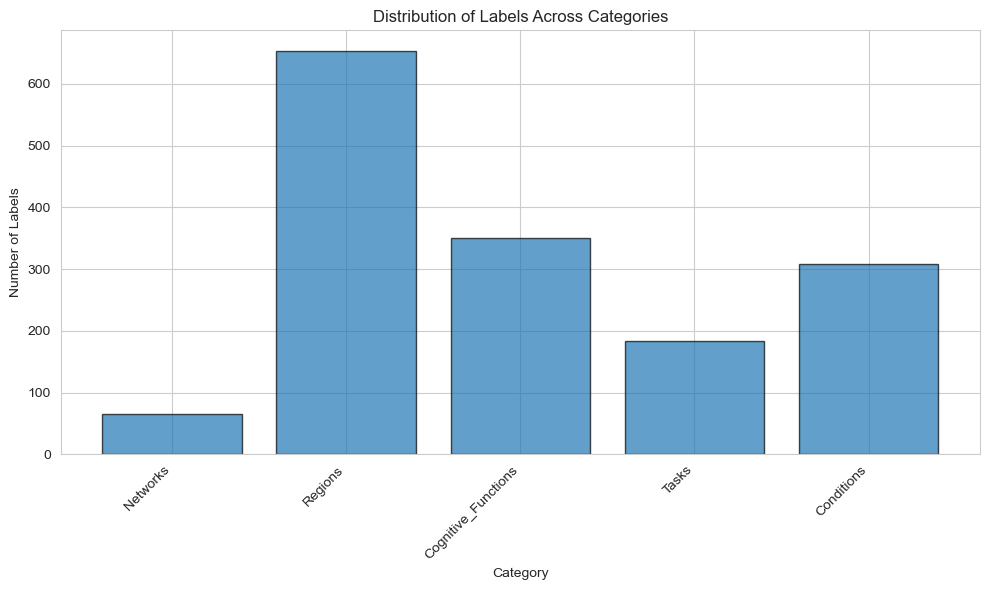

In [6]:
# Visualize category distribution
plt.figure(figsize=(10, 6))
plt.bar(category_counts.keys(), category_counts.values(), alpha=0.7, edgecolor='black')
plt.xlabel('Category')
plt.ylabel('Number of Labels')
plt.title('Distribution of Labels Across Categories')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [7]:
# Show example labels from each category
print("Example labels per category:\n")
for cat in categories:
    examples = [label for label, cats in label_categories.items() if cats.get(cat, False)][:10]
    print(f"{cat}:")
    for ex in examples:
        print(f"  - {ex}")
    print()

Example labels per category:

Networks:
  - alff
  - dacc
  - dalff
  - dlpfc
  - dmpfc
  - dorsal
  - dorso
  - falff
  - hubs
  - lpfc

Regions:
  - basal
  - bnst
  - body
  - broca
  - caudal
  - center
  - core
  - corpus
  - crus
  - cuneus

Cognitive_Functions:
  - attend
  - aware
  - belief
  - bias
  - biased
  - biases
  - choice
  - choose
  - chose
  - chosen

Tasks:
  - code
  - codes
  - coding
  - count
  - cued
  - cueing
  - digit
  - digits
  - error
  - errors

Conditions:
  - adhd
  - adult
  - aged
  - ageing
  - ages
  - aging
  - apathy
  - ataxia
  - attack
  - aura



## Part 3: Create Paper-Level Dataset

Now we'll map papers to their categorized labels.

In [10]:
# Run dataset creation
# This can also be run from command line: python -m neurovlm.create_labeled_dataset

from neurovlm.create_labeled_dataset import create_paper_dataset, create_binary_labels

# Create paper-level dataset
df = pd.read_csv('paper_labels.csv', index_col=0)
df.head()

,Networks,Regions,Cognitive_Functions,Tasks,Conditions
pmid,,,,,
24911975,[],"['broca', 'area left', 'auditory cortices', 'b...",['speech'],[],[]
22884992,[],"['motor', 'area right', 'index finger', 'left ...","['cued', 'anterior cingulate gyrus']","['cued', 'finger movements']",[]
15722210,[],"['fields', 'motor', 'left frontal', 'posterior...","['anterior cingulate cortex', 'anterior tempor...",['rest'],['normal subjects']
21930137,[],"['key regions', 'left hemisphere', 'right hemi...","['memory', 'double dissociation', 'spatial mem...",['memory task'],[]
21930160,[],[],[],[],[]


In [11]:
# Create binary version
binary_df = pd.read_csv('paper_labels_binary.csv', index_col=0)
binary_df.head()

,Networks,Regions,Cognitive_Functions,Tasks,Conditions
pmid,,,,,
24911975,0,1,1,0,0
22884992,0,1,1,1,0
15722210,0,1,1,1,1
21930137,0,1,1,1,0
21930160,0,0,0,0,0


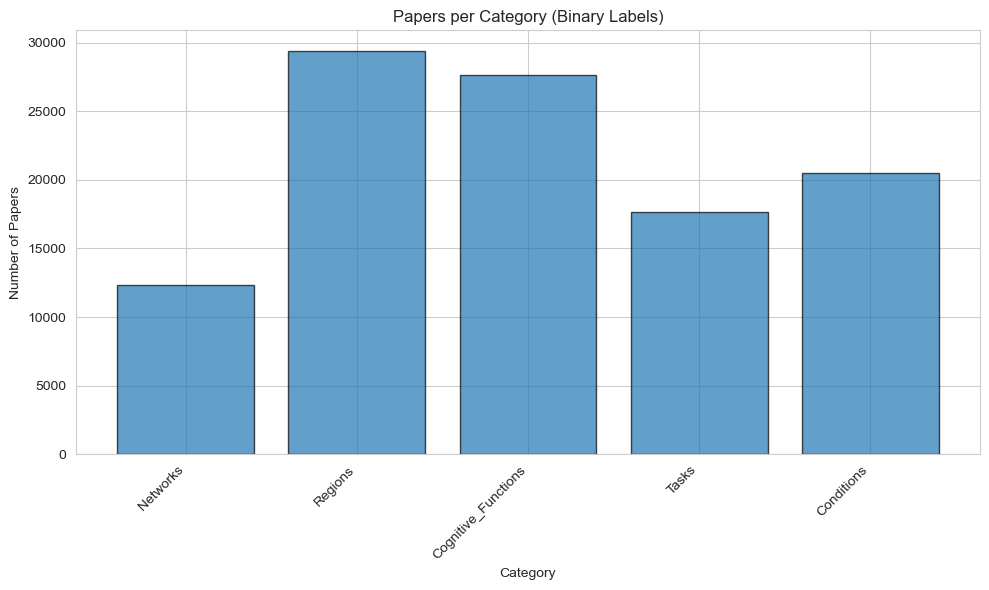

Class balance:
  Networks: 0.400 (positive ratio)
  Regions: 0.954 (positive ratio)
  Cognitive_Functions: 0.896 (positive ratio)
  Tasks: 0.574 (positive ratio)
  Conditions: 0.666 (positive ratio)


In [12]:
# Visualize class distribution
category_sums = binary_df[categories].sum()

plt.figure(figsize=(10, 6))
plt.bar(categories, category_sums.values, alpha=0.7, edgecolor='black')
plt.xlabel('Category')
plt.ylabel('Number of Papers')
plt.title('Papers per Category (Binary Labels)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Class balance:")
for cat in categories:
    ratio = binary_df[cat].mean()
    print(f"  {cat}: {ratio:.3f} (positive ratio)")

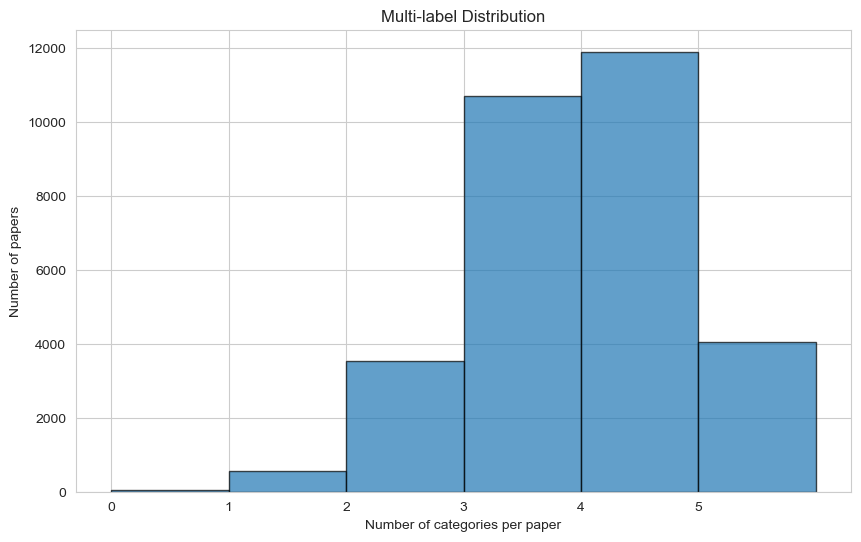

Average categories per paper: 3.49
Papers with 0 categories: 74
Papers with 1 category: 570
Papers with 2+ categories: 30182


In [13]:
# Multi-label statistics
num_categories_per_paper = binary_df[categories].sum(axis=1)

plt.figure(figsize=(10, 6))
plt.hist(num_categories_per_paper, bins=range(0, num_categories_per_paper.max()+2), 
         edgecolor='black', alpha=0.7)
plt.xlabel('Number of categories per paper')
plt.ylabel('Number of papers')
plt.title('Multi-label Distribution')
plt.xticks(range(0, num_categories_per_paper.max()+1))
plt.show()

print(f"Average categories per paper: {num_categories_per_paper.mean():.2f}")
print(f"Papers with 0 categories: {(num_categories_per_paper == 0).sum()}")
print(f"Papers with 1 category: {(num_categories_per_paper == 1).sum()}")
print(f"Papers with 2+ categories: {(num_categories_per_paper >= 2).sum()}")

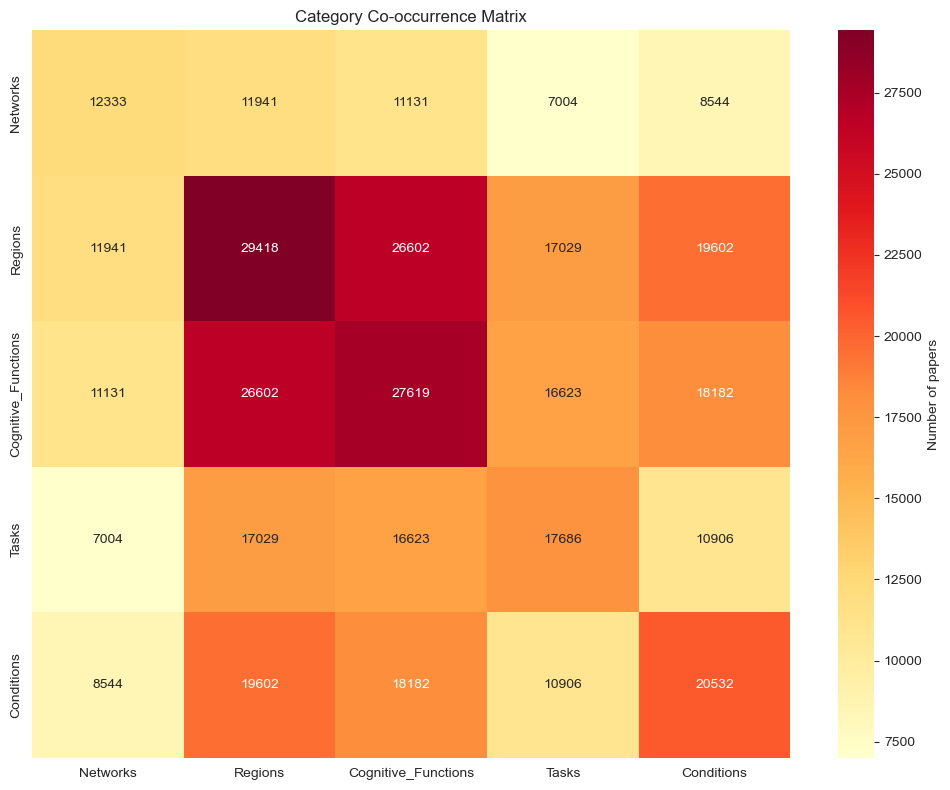

In [14]:
# Category co-occurrence heatmap
co_occurrence = np.zeros((len(categories), len(categories)))

for i, cat1 in enumerate(categories):
    for j, cat2 in enumerate(categories):
        both = ((binary_df[cat1] == 1) & (binary_df[cat2] == 1)).sum()
        co_occurrence[i, j] = both

plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence, annot=True, fmt='.0f', cmap='YlOrRd',
            xticklabels=categories, yticklabels=categories, cbar_kws={'label': 'Number of papers'})
plt.title('Category Co-occurrence Matrix')
plt.tight_layout()
plt.show()

## Part 4: Train Classification Models

Now we'll train and compare multiple classification models.

In [ ]:
# Load and align brain vectors with labels
from neurovlm.classification_models import load_and_align_data

X, pmids_aligned, y = load_and_align_data(labels_file='paper_labels_binary.csv')

print(f"Aligned dataset:")
print(f"  Brain vectors: {X.shape}")
print(f"  Labels: {y.shape}")
print(f"  PMIDs: {len(pmids_aligned)}")

In [ ]:
# Split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

### Model 1: PCA + Ridge Baseline

In [ ]:
from neurovlm.classification_models import PCABaseline, evaluate_model, print_evaluation_results

# Train PCA baseline
pca_model = PCABaseline(variance_threshold=0.95, C=1.0, random_state=42)
pca_model.fit(X_train, y_train, verbose=True)

# Evaluate
y_test_pred_pca = pca_model.predict(X_test)
y_test_proba_pca = pca_model.predict_proba(X_test)

pca_results = evaluate_model(y_test, y_test_pred_pca, y_test_proba_pca)
print("\n### PCA + Ridge Results ###")
print_evaluation_results(pca_results)

In [ ]:
# Visualize PCA variance explained
cumsum_var = np.cumsum(pca_model.pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(cumsum_var)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.axhline(y=0.99, color='g', linestyle='--', label='99% variance')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA Variance Explained')
plt.legend()
plt.grid(True)
plt.show()

print(f"Number of components: {pca_model.pca.n_components_}")
print(f"Total variance explained: {cumsum_var[-1]:.4f}")

### Model 2: XGBoost

In [ ]:
from neurovlm.classification_models import BoostedTreesClassifier

# Train XGBoost
xgb_model = BoostedTreesClassifier(
    library='xgboost',
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)
xgb_model.fit(X_train, y_train, verbose=True)

# Evaluate
y_test_pred_xgb = xgb_model.predict(X_test)
y_test_proba_xgb = xgb_model.predict_proba(X_test)

xgb_results = evaluate_model(y_test, y_test_pred_xgb, y_test_proba_xgb)
print("\n### XGBoost Results ###")
print_evaluation_results(xgb_results)

In [ ]:
# Feature importance
importance = xgb_model.get_feature_importance()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, cat in enumerate(categories):
    top_k = 20
    top_indices = np.argsort(importance[cat])[-top_k:]
    
    axes[i].barh(range(top_k), importance[cat][top_indices])
    axes[i].set_yticks(range(top_k))
    axes[i].set_yticklabels([f"Feature {idx}" for idx in top_indices])
    axes[i].set_xlabel('Importance')
    axes[i].set_title(f'{cat} - Top {top_k} Features')

axes[-1].axis('off')  # Hide extra subplot
plt.tight_layout()
plt.show()

### Model Comparison

In [ ]:
# Compare models
comparison_data = {
    'PCA + Ridge': pca_results,
    'XGBoost': xgb_results
}

# Create comparison dataframe
comparison_rows = []
for model_name, results in comparison_data.items():
    for cat in categories:
        comparison_rows.append({
            'Model': model_name,
            'Category': cat,
            'F1': results[cat]['f1'],
            'Precision': results[cat]['precision'],
            'Recall': results[cat]['recall'],
            'ROC-AUC': results[cat]['roc_auc']
        })

comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df.to_string(index=False))

In [ ]:
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['F1', 'Precision', 'Recall']
for i, metric in enumerate(metrics):
    pivot_df = comparison_df.pivot(index='Category', columns='Model', values=metric)
    pivot_df.plot(kind='bar', ax=axes[i], alpha=0.8)
    axes[i].set_title(f'{metric} Score Comparison')
    axes[i].set_ylabel(metric)
    axes[i].set_xlabel('Category')
    axes[i].legend(title='Model')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
# Overall performance summary
print("\n=== Overall Performance Summary ===")
print(f"\n{'Model':<20} {'Macro F1':>12} {'Micro F1':>12}")
print("-" * 45)

for model_name, results in comparison_data.items():
    macro_f1 = results['macro_avg']['f1']
    micro_f1 = results['micro_avg']['f1']
    print(f"{model_name:<20} {macro_f1:>12.3f} {micro_f1:>12.3f}")

## Part 5: Error Analysis

Let's analyze where the best model makes mistakes.

In [ ]:
# Use XGBoost for error analysis (assuming it's the best model)
best_model = xgb_model
y_pred = y_test_pred_xgb

# Confusion matrices per category
from sklearn.metrics import multilabel_confusion_matrix

mcm = multilabel_confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, cat in enumerate(categories):
    cm = mcm[i]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'])
    axes[i].set_title(f'{cat} Confusion Matrix')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Find most confident correct and incorrect predictions
for i, cat in enumerate(categories):
    print(f"\n=== {cat} ===")
    
    # Most confident correct predictions
    correct = (y_test[:, i] == y_pred[:, i])
    confident_correct = np.argsort(y_test_proba_xgb[:, i] * correct)[-5:]
    
    print("Most confident correct:")
    for idx in confident_correct[::-1]:
        if correct[idx]:
            print(f"  True={y_test[idx, i]}, Pred={y_pred[idx, i]}, Prob={y_test_proba_xgb[idx, i]:.3f}")
    
    # Most confident incorrect predictions
    incorrect = (y_test[:, i] != y_pred[:, i])
    if incorrect.sum() > 0:
        confident_incorrect = np.argsort(np.abs(y_test_proba_xgb[:, i] - 0.5) * incorrect)[-5:]
        
        print("Most confident incorrect:")
        for idx in confident_incorrect[::-1]:
            if incorrect[idx]:
                print(f"  True={y_test[idx, i]}, Pred={y_pred[idx, i]}, Prob={y_test_proba_xgb[idx, i]:.3f}")

## Summary

This notebook demonstrated:

1. **Data Inspection**: Loaded and analyzed ~2,458 ngram labels and ~30,826 papers
2. **LLM Categorization**: Used Claude to categorize labels into 5 semantic categories
3. **Dataset Creation**: Built multi-label dataset aligning brain vectors with categories
4. **Model Training**: Trained and compared PCA+Ridge and XGBoost classifiers
5. **Evaluation**: Analyzed per-category and aggregate performance
6. **Error Analysis**: Investigated model mistakes and confidence

### Next Steps

- Fine-tune hyperparameters based on validation results
- Try ensemble methods combining multiple models
- Investigate category-specific features or preprocessing
- Apply best model to new unlabeled brain maps
- Analyze feature importance to understand which brain regions drive each category